In [4]:
import numpy as np
import torch
import torchvision
from torch.utils.data import dataloader
import torchvision.transforms.functional as TF

from tqdm import tqdm
import mlflow
import os
import matplotlib.pyplot as plt

In [5]:
import cv2
from dataset import mask_to_centers, DOTA_MEAN, DOTA_STD
from inference import draw_centers, load_checkpoint, predict_sliding_window, find_peaks, compute_metrics_at_threshold, match_centers, get_gaussian_weight_map
from loss import CenterLoss

In [6]:
RANDOM_STATE = 1619
TILE_SIZE = 512
STRIDE = 384
THRESHOLD = 0.3
MATCH_RADIUS = 20.0


In [7]:
device ="mps" if torch.backends.mps.is_available() else  "cuda" if torch.cuda.is_available() else "cpu"

In [8]:
## mlflow set-up
experiment_name = "co-patch-attack-trial1"
mlflow.set_experiment(experiment_name)

2026/02/22 15:56:41 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/22 15:56:41 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/22 15:56:41 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/22 15:56:41 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/22 15:56:41 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/22 15:56:41 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/22 15:56:42 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/22 15:56:42 INFO alembic.runtime.migration: Will assume non-transactional DDL.


<Experiment: artifact_location='/Users/co/Code/projet-vision/mlruns/1', creation_time=1771274040764, experiment_id='1', last_update_time=1771274040764, lifecycle_stage='active', name='co-patch-attack-trial1', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [9]:
# Init the attack
img_path = "segdata/DOTA/DOTA_PLANES_TILED/train/image/P0023_obj_27.png"
mask_path = "segdata/DOTA/DOTA_PLANES_TILED/train/mask/P0023_obj_27.png"
img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
gt_centers = mask_to_centers(gt_mask * 255)

# base_features = torch.load("segdata/DOTA/DOTA_PLANES_TILED_CACHED_FEATURES/base/train/P0022_obj_6.pt")

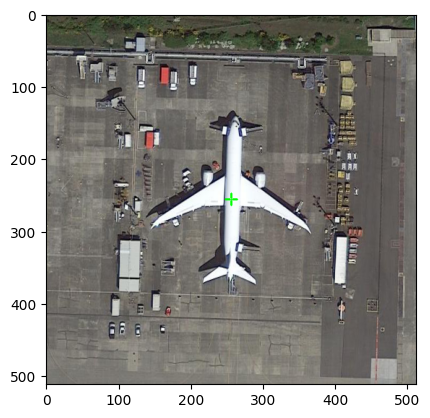

In [10]:
thickness = max(2, int(max(img.shape[:2]) / 500))
radius = max(8, int(max(img.shape[:2]) / 200))
vis_gt = draw_centers(img, gt_centers, (0, 255, 0), radius=radius, thickness=thickness)
plt.imshow(vis_gt)

In [11]:
# load the model
ckpt_path = "runs/16_02-21_05_12_BASE_animal-variation.pth"
model = load_checkpoint(ckpt_path, device)
model.eval();


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

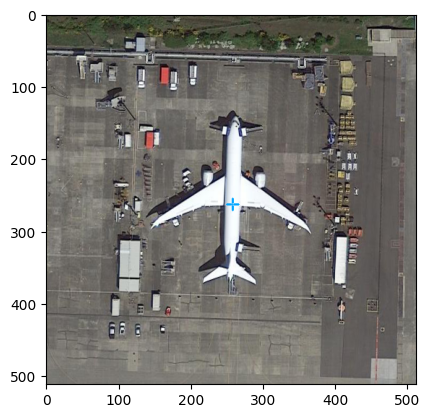

In [12]:
# Predict:
prob_map = predict_sliding_window(model, img, device=device)
pred_centers = find_peaks(prob_map, threshold=THRESHOLD)
heatmap = prob_map
vis_pred = draw_centers(img, pred_centers, (0, 165, 255), radius=radius, thickness=thickness)
plt.imshow(vis_pred)

In [13]:
tp, fp, fn = match_centers(gt_centers, pred_centers)
print("TP = ", tp, "| FP = ", fp, "| FN = ", fn)

TP =  1 | FP =  0 | FN =  0


## Naive Attack

In [14]:
# Add Patch on the top corner
PATCH_SIZE = 72
patch = np.zeros_like(img)
patch[0:PATCH_SIZE, 0:PATCH_SIZE] = 1
weight_map = get_gaussian_weight_map(TILE_SIZE, device)

In [15]:
def predict(model, x, weight_map, device):
    x_t = torch.from_numpy(x).permute(2, 0, 1).float() / 255.0
    x_t = TF.normalize(x_t, DOTA_MEAN, DOTA_STD)
    x_t = x_t.unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x_t)
        prob = torch.sigmoid(logits).squeeze()
        
    prob_map = (prob * weight_map).cpu().numpy()
    print("Maximum Prob = ", prob_map.max().max())

    return prob_map

In [16]:
def show_attack_results(x0, x, y0, y):
    
    y0_centers = find_peaks(y0, threshold=THRESHOLD)
    prediction0 = draw_centers(x0, y0_centers, (0, 165, 255), radius=radius, thickness=thickness)

    y_centers = find_peaks(y, threshold=THRESHOLD)
    prediction = draw_centers(x, y_centers, (0, 165, 255), radius=radius, thickness=thickness)

    ## Normalization
    # Make x and vis_pred float [0,1] too (if they are uint8 or 0..255 float)
    prediction0 = prediction0.astype(np.float32) / 255.0
    prediction = prediction.astype(np.float32) / 255.0

    # Normalize prob_map to [0,1]
    y0_f = y0.astype(np.float32)
    pmin0, pmax0 = y0_f.min(), y0_f.max()
    y0_f_norm = (y0_f - pmin0) / (pmax0 - pmin0 + 1e-8)
    # Colormap returns float in [0,1]
    y0_color = plt.get_cmap("magma")(y0_f_norm)[..., :3]
    
    # Normalize prob_map to [0,1]
    y_f = y.astype(np.float32)
    pmin, pmax = y_f.min(), y_f.max()
    y_f_norm = (y_f - pmin) / (pmax - pmin + 1e-8)
    # Colormap returns float in [0,1]
    y_color = plt.get_cmap("magma")(y_f_norm)[..., :3]
    
    fig, ax = plt.subplots(2,2, figsize=(12,12))
    y0_max = y0.max()
    y_max = y.max()
    
    ax[0,0].imshow(prediction0)
    ax[0,0].set_title(f"Original Image and Prediction | Max = {y0_max:.2f}")
    ax[0,1].imshow(y0_color)
    ax[0,1].set_title("Original Prob")
    ax[1,0].imshow(prediction)
    ax[1,0].set_title(f"Attacked Image and Prediction | Max = {y_max:.2f}")
    ax[1,1].imshow(y_color)
    ax[1,1].set_title("Attacked  Prob")

    for ax in fig.axes:
        ax.axis("off")
    plt.show()

Maximum Prob =  0.5778244
Maximum Prob =  0.5680766


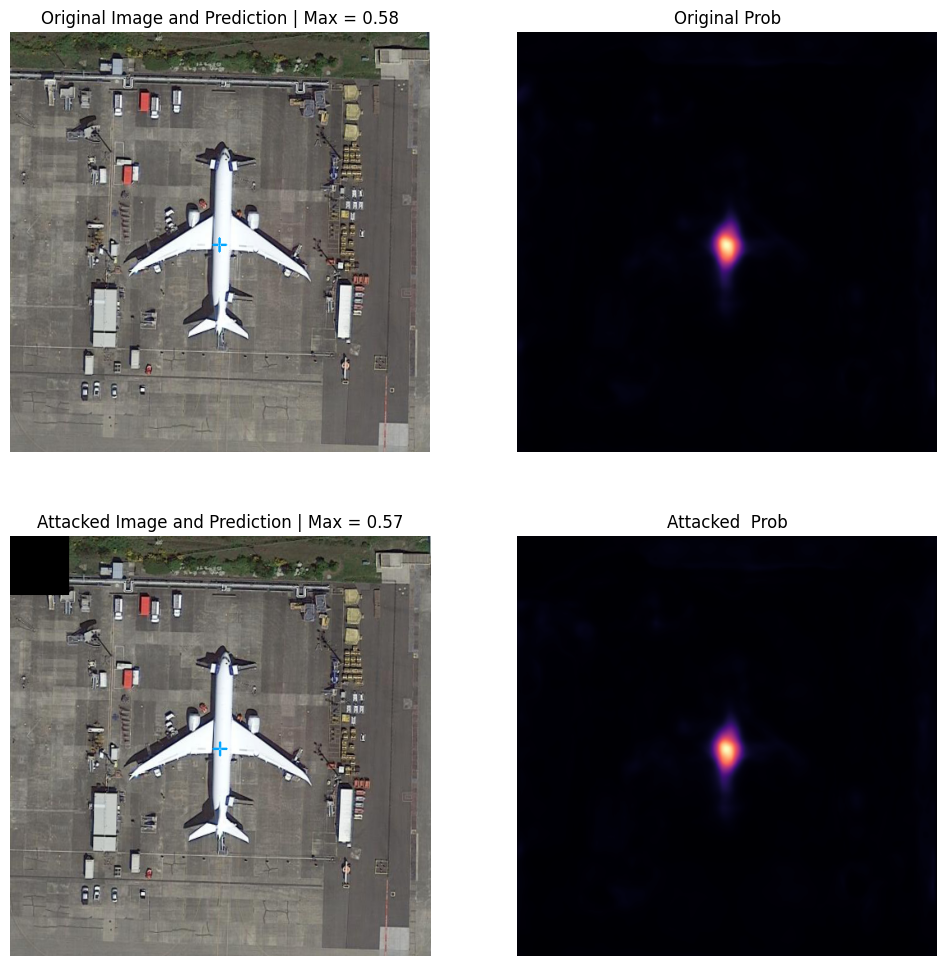

In [17]:
x0 = img
x = x0*(1-patch)
y0 = predict(model, x0, weight_map, device)
y = predict(model, x, weight_map, device)
show_attack_results(x0, x, y0, y)

## Iteration of First Attack

In [18]:
def x_to_torch(x):
    x_t = torch.from_numpy(x).permute(2, 0, 1).float() / 255.0
    x_t = TF.normalize(x_t, DOTA_MEAN, DOTA_STD)
    x_t = x_t.unsqueeze(0).to(device)
    return x_t

In [19]:
def normalize(x_t):
    x = TF.normalize(x_t, DOTA_MEAN, DOTA_STD)
    x = x.unsqueeze(0).to(device)
    return x

In [20]:
cefunction = CenterLoss().to(device)
x0_t = x_to_torch(x0)

with torch.no_grad():
  y0_t = model(x0_t)
  x_min, x_max = x0_t.min().item(), x0_t.max().item()
  
attack_init = torch.nn.Parameter(torch.rand_like(x0_t))

patch_t = torch.zeros_like(x0_t).to(device)
patch_t[:,:,0:PATCH_SIZE,0:PATCH_SIZE] = 1

# weight_map_t = torch.from_numpy(weight_map)
attack = torch.nn.Parameter(attack_init.clone())
optimizer = torch.optim.AdamW([attack], lr=0.5)

for i in range(1):
    optimizer.zero_grad()

    x_attacked = x0_t * (1 - patch_t) + attack * patch_t
    y_attacked = torch.sigmoid(model(x_attacked)) * (1-weight_map)
    ce = cefunction(y_attacked, y0_t)

    print(i, float(ce))
    loss = -ce
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        attack.clamp_(x_min*1.5, x_max*1.5)  # keeps it in image range, no new graph

# Double backward error
# for i in range(2):
#   optimizer.zero_grad()
#   x_attacked = x0_t*(1-patch_t)+attack*patch_t
#   y_attacked = torch.sigmoid(model(x_attacked))*weight_map # optimize only the attack
#   ce = cefunction(y_attacked,y0_t)
#   print(i,float(ce))
#   ce = -ce # on veut MAXIMISER la cross entropy puisqu'on attaque
#   ce.backward()
#   #attack.grad = attack.grad.sign()
#   optimizer.step()
# #   with torch.no_grad():
# #       # l'attaque doit être dans le domaine image
# #       attack = torch.clamp(attaque, 0,1)
#   attack = attack.detach().requires_grad_(True)
#   attack = torch.nn.Parameter(attack.clone())
# #   if i<20:
# #       optimizer = torch.optim.SGD([attack],lr=0.1)
# #   else:
# #       optimizer = torch.optim.SGD([attack],lr=0.05)

0 103.06932067871094


/var/folders/r6/vjff12js0_3d1j8lxkmmhthr0000gn/T/ipykernel_79630/891515663.py:24: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  print(i, float(ce))


In [21]:
mean = torch.tensor(DOTA_MEAN, device=device).view(1, 3, 1, 1)
std = torch.tensor(DOTA_STD, device=device).view(1, 3, 1, 1)

x_attacked_un = (x_attacked * std + mean)
x_attacked_un = (x_attacked_un + x_attacked_un.min())/(x_attacked_un.min()+x_attacked_un.max())*255
img_attacked = x_attacked_un.cpu().detach().numpy().squeeze().transpose(1,2,0)
prediction_attacked = y_attacked.cpu().detach().numpy().squeeze()

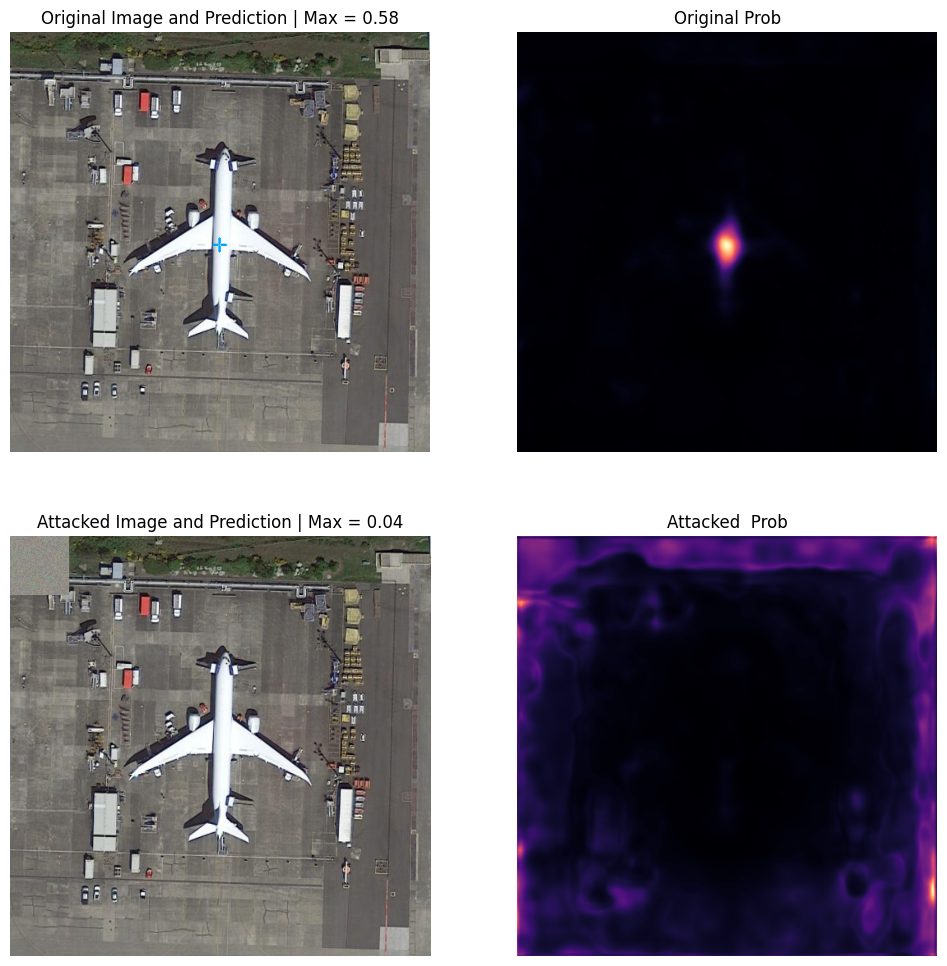

In [22]:
show_attack_results(x0, img_attacked, y0,prediction_attacked )

## Second Attack 

In [23]:
cefunction = CenterLoss().to(device)
x0_t = x_to_torch(x0)

min = TF.normalize(torch.zeros_like(x0_t), DOTA_MEAN, DOTA_STD)
max = TF.normalize(torch.ones_like(x0_t), DOTA_MEAN, DOTA_STD)

with torch.no_grad():
  y0_t = torch.sigmoid(model(x0_t))
  
attack_init = torch.nn.Parameter(torch.rand_like(x0_t))

patch_t = torch.zeros_like(x0_t).to(device)
patch_t[:,:,0:PATCH_SIZE,0:PATCH_SIZE] = 1

# weight_map_t = torch.from_numpy(weight_map)
attack = torch.nn.Parameter(attack_init.clone())
optimizer = torch.optim.AdamW([attack], lr=0.5)

for i in range(1):
    optimizer.zero_grad()

    x_attacked = x0_t * (1 - patch_t) + attack * patch_t
    y_attacked = torch.sigmoid(model(x_attacked))#* weight_map
    ce = cefunction(y0_t, y_attacked)
    # ce = cefunction(y0_t * (1-weight_map), y_attacked)

    print(i, float(ce))
    loss = -ce
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        attack.clamp_(min, max)  # keeps it in image range, no new graph


0 0.20551864802837372


In [24]:
def numpyfy_attack_results(x_attacked, y_attacked):
    mean = torch.tensor(DOTA_MEAN, device=device).view(1, 3, 1, 1)
    std = torch.tensor(DOTA_STD, device=device).view(1, 3, 1, 1)

    x_attacked_un = (x_attacked * std + mean)
    x_min, x_max = (x_attacked_un*(1-patch_t)).min(), (x_attacked_un*(1-patch_t)).max()
    x_attacked_un = (x_attacked_un + x_min)/(x_min+ x_max)*255
    img_attacked = x_attacked_un.cpu().detach().numpy().squeeze().transpose(1,2,0)
    prediction_attacked = y_attacked.cpu().detach().numpy().squeeze()
    
    return img_attacked, prediction_attacked

In [25]:
at = attack.cpu().detach().numpy().squeeze().transpose(1,2,0)
x = x0 * (1 - patch) + at * patch
y = predict(model, x, weight_map, device)
y.max()

Maximum Prob =  0.5646455


0.5646455

In [26]:
img_not_attacked, prediction_not_attacked = numpyfy_attack_results(x0_t, y0_t*weight_map)

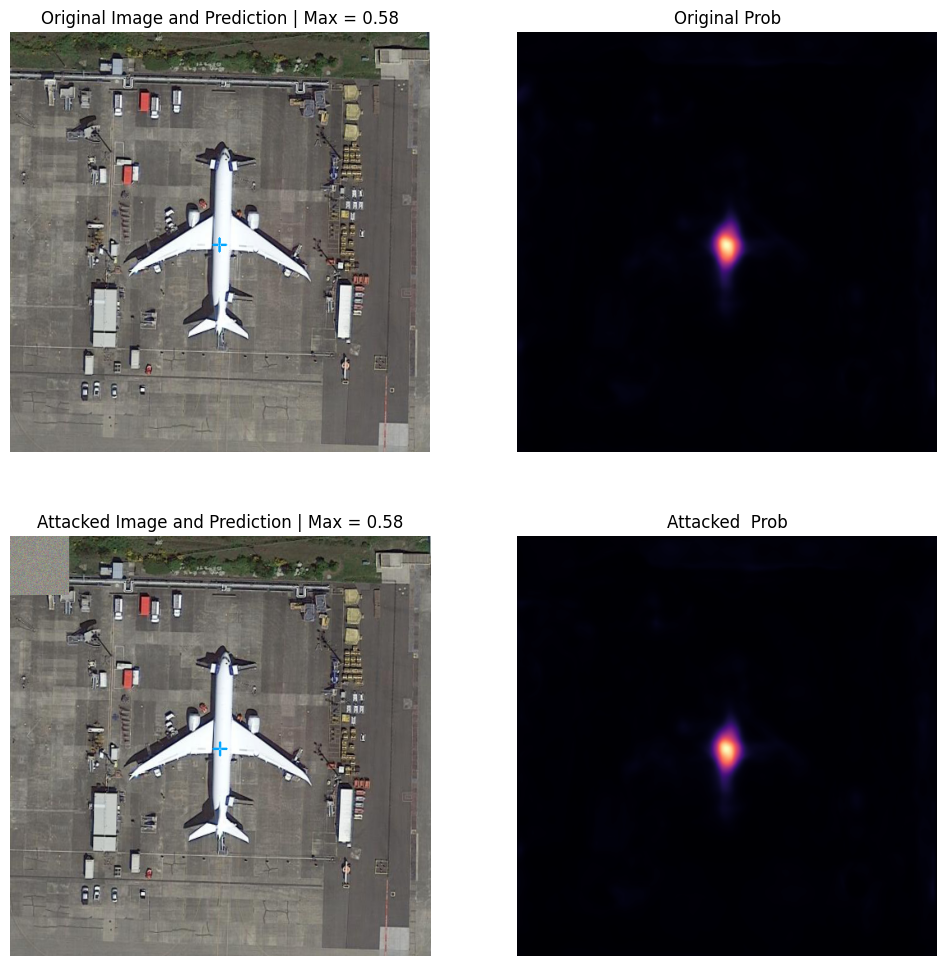

In [27]:
img_attacked, prediction_attacked = numpyfy_attack_results(x_attacked, y_attacked*weight_map)
show_attack_results(img_not_attacked, img_attacked, prediction_not_attacked, prediction_attacked )

## Iter 3: boxed around plane patch

### 

In [28]:
NORMALIZED_MIN = TF.normalize(torch.zeros_like(x0_t), DOTA_MEAN, DOTA_STD)
NORMALIZED_MAX = TF.normalize(torch.ones_like(x0_t), DOTA_MEAN, DOTA_STD)

In [29]:
PATCH_SIZE = 72
patch = np.zeros_like(img)
patch[0:PATCH_SIZE, 0:PATCH_SIZE] = 1
weight_map = get_gaussian_weight_map(TILE_SIZE, device)

In [30]:
gt_mask_t = torch.from_numpy(gt_mask).to(device)

In [31]:
from skimage.morphology import erosion, dilation, binary_erosion, opening, closing, white_tophat, reconstruction

def create_mask(x0_t, gt_mask, thickness):
    mask_t = torch.zeros_like(x0_t).to(device)
    kernel = np.ones([thickness,thickness])
    gt_mask_erosion = erosion(gt_mask, kernel)
    gt_mask_t = torch.from_numpy(gt_mask).to(device)
    gt_mask_erosion_t = torch.from_numpy(gt_mask_erosion).to(device)

    print("Patch around the plane")
    mask_t += (gt_mask_t-gt_mask_erosion_t)>0 
          
    return mask_t

In [32]:
def train_attack(x0, gt_mask, iter = 10, thickness = 16):
    cefunction = CenterLoss().to(device)
    x0_t = x_to_torch(x0)

    with torch.no_grad():
        y0_t = torch.sigmoid(model(x0_t))
    
    attack_init = torch.nn.Parameter(torch.rand_like(x0_t))
    
    mask_t = create_mask(x0_t, gt_mask, thickness)
    attack = torch.nn.Parameter(attack_init.clone())
    optimizer = torch.optim.AdamW([attack], lr=0.5)

    for i in range(iter):
        optimizer.zero_grad()

        x_attacked = x0_t * (1-mask_t) + attack * mask_t
        y_attacked = torch.sigmoid(model(x_attacked))#* weight_map
        loss = - cefunction(y0_t, y_attacked)
        # ce = cefunction(y0_t * (1-weight_map), y_attacked)
        # print(i, float(ce))
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            attack.clamp_(NORMALIZED_MIN, NORMALIZED_MAX)  # keeps it in image range, no new graph
            
    return x_attacked, y_attacked, attack, mask_t

Patch around the plane


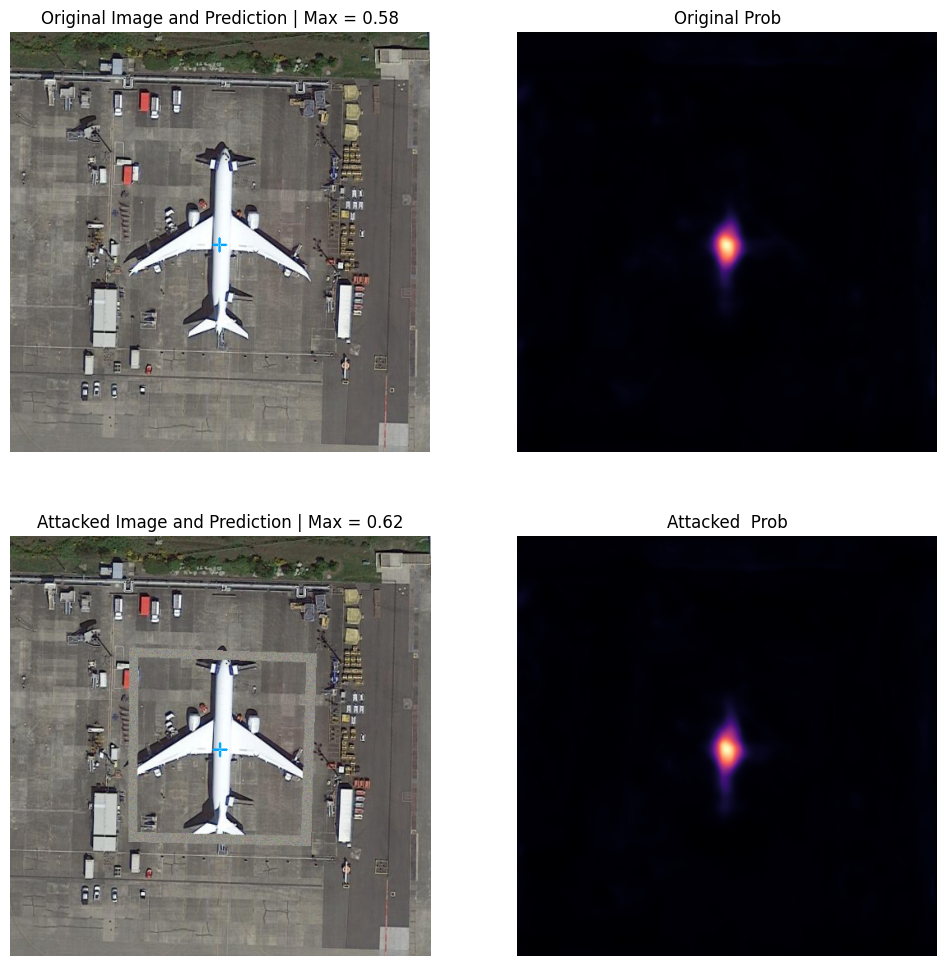

In [33]:
gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

x_attacked, y_attacked, attack, mask_t = train_attack(img, gt_mask, iter=1, thickness=24)
img_not_attacked, prediction_not_attacked = numpyfy_attack_results(x0_t, y0_t*weight_map)
img_attacked, prediction_attacked = numpyfy_attack_results(x_attacked, y_attacked*weight_map)
show_attack_results(img_not_attacked, img_attacked, prediction_not_attacked, prediction_attacked)

## Batch

In [34]:
import importlib
import dataset
import train
importlib.reload(dataset)
importlib.reload(train)

from dataset import PreTiledDataset
from torch.utils.data import DataLoader
import random
from train import generate_run_id, segdino_collate 
from codenames import generate_codename
from dataset import CachedFeaturesDataset
from extract_features import extract_and_save_features, get_cache_dir
from inference import find_peaks, match_centers
from loss import CenterLoss
from model import DecoderOnly
from torch.utils.data import random_split, DataLoader


DATA_DIR = "segdata/DOTA/DOTA_PLANES_TILED"
BATCH_SIZE = 16
NUM_WORKERS = 4
g = torch.Generator().manual_seed(RANDOM_STATE)

In [35]:
torch.manual_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
os.makedirs("runs", exist_ok=True)
run_id = generate_run_id("small")

# pth_path = os.path.join("runs", f"{run_id}.pth")
# csv_path = os.path.join("runs", f"{run_id}.csv")

In [36]:
dataset = PreTiledDataset(DATA_DIR,"train",return_empty=False)
dataset_test = PreTiledDataset(DATA_DIR,"test", return_empty=True)

In [37]:
validation_ratio = 0.3
n_val = int(len(dataset) * validation_ratio)
n_train = len(dataset) - n_val
dataset_train, dataset_validation = random_split(dataset, [n_train, n_val], generator=g)

In [38]:
from skimage.morphology import erosion, dilation, binary_erosion, opening, closing, white_tophat, reconstruction
import kornia.morphology as K
_kernel_cache = {}
def _get_kernel(thickness, device):
    key = (thickness, str(device))
    kernel = _kernel_cache.get(key)
    if kernel is None or kernel.device != device:
        kernel = torch.ones((thickness, thickness), device=device)
        _kernel_cache[key] = kernel
    return kernel
def create_patch(masks_t, thickness, metas, device):
    # Vectorized erosion on the whole batch.
    kernel = _get_kernel(thickness, masks_t.device)
    # masks = masks_t.unsqueeze(1).float()
    masks = masks_t.unsqueeze(0).unsqueeze(1).float()
    eroded = K.erosion(masks, kernel)
    return (masks - eroded) > 0


In [39]:
def validate_attack(model, attack, validation_loader):
    model.eval()
    cefunction = CenterLoss().to(device)
    validation_loss = 0.0
    with torch.inference_mode():
        for imgs_t, targets_t, metas, masks_t in tqdm(validation_loader, desc="validation", leave=False):
            imgs_t = imgs_t.to(device, non_blocking=True)
            masks_t = masks_t.to(device, non_blocking=True)
            pred_t = torch.sigmoid(model(imgs_t))
            patch_t = create_patch(masks_t, thickness, metas, device)
            imgs_attacked_t = torch.where(patch_t, attack, imgs_t)
            pred_attacked_t = torch.sigmoid(model(imgs_attacked_t))
            loss = -cefunction(pred_t, pred_attacked_t)
            validation_loss += loss.item()
    return validation_loss


In [40]:
def train_attack(model,n_epoch, train_loader, validation_loader, learning_rate = 0.5):# Init the attack
    with mlflow.start_run() as run:
        print(f"ML Flow run id {run}")
        
        mlflow.log_param("n_epoch", n_epoch)
        mlflow.log_param("learning_rate", learning_rate)
        model.eval()
        # freeze gradient
        for p in model.parameters():
            p.requires_grad_(False)
        cefunction = CenterLoss().to(device)
        attack = None
        optimizer = None
        # epoch loop
        global_step = 0
        for epoch in tqdm(range(1, n_epoch+1), desc=run_id):
            # loop throught the batch
            training_loss = 0.0
            batch_count = 0
            
            for imgs_t, _, metas, masks_t in tqdm(train_loader, desc="train", leave=False):
                imgs_t = imgs_t.to(device, non_blocking=True)
                masks_t = masks_t.to(device, non_blocking=True)
                with torch.no_grad():
                    pred_t = torch.sigmoid(model(imgs_t))
                    patch_t = create_patch(masks_t, thickness, metas, device)
                    
                if attack is None:
                    attack = torch.nn.Parameter(torch.rand_like(imgs_t[:1]))
                    optimizer = torch.optim.AdamW([attack], lr=learning_rate)
                for _ in range(10):
                    optimizer.zero_grad(set_to_none=True)
                    imgs_attacked_t = torch.where(patch_t, attack, imgs_t)
                    pred_attacked_t = torch.sigmoid(model(imgs_attacked_t))
                    
                    loss = - cefunction(pred_t, pred_attacked_t)
                    loss.backward()
                    optimizer.step()
                    
                    with torch.no_grad():
                        attack.clamp_(NORMALIZED_MIN, NORMALIZED_MAX)  # keeps it in image range, no new graph
                
                training_loss += loss.item()
                batch_count += 1
                global_step += 1
                
                mlflow.log_metric("training_loss", training_loss, step=global_step)
                if batch_count % 5 == 0:
                    tqdm.write(f"BATCH {batch_count:3d} | train: {training_loss/5:.4f}")
                    training_loss = 0
                    attack_path = "runs/attack.pt"
                    torch.save(attack.detach().cpu(), attack_path)
                    mlflow.log_artifact(attack_path)
            
            validation_loss = validate_attack(model, attack, validation_loader)
            mlflow.log_metric("validation_loss", validation_loss, step=global_step)     
                       
            tqdm.write(f"EPOCH {epoch:3d} | train: {training_loss:.4f} | validation_loss: {validation_loss}")
        
        # save
        attack_path = "runs/attack.pt"
        torch.save(attack.detach().cpu(), attack_path)
        mlflow.log_artifact(attack_path)
    return attack, mlflow.active_run().info.run_id


#### Attack

In [41]:
# Data
batch_size = 1
train_loader = DataLoader(
    dataset_train,
    batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS,
    drop_last=True, collate_fn=segdino_collate, persistent_workers=True
)

validation_loader = DataLoader(
    dataset_validation,
    batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS,
    drop_last=True, collate_fn=segdino_collate, persistent_workers=True
)
 
test_loader = DataLoader(dataset_test,
    batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS,
    collate_fn=segdino_collate, persistent_workers=True
)

n_epoch = 1
thickness = 12

print(f'Len loader train {len(train_loader)}')
print(f'Len loader validation {len(validation_loader)}')
print(f'Len loader test {len(test_loader)}')

Len loader train 4625
Len loader validation 1981
Len loader test 753


In [42]:
# train_attack(model, n_epoch, train_loader, validation_loader)

#### Eval

In [43]:
interesting_images = ["P0023_obj_27.png"]

In [44]:
run_id = "489801f736b94ae684cfbe47f2b09a72"
client = mlflow.tracking.MlflowClient()
path = client.download_artifacts(run_id, "attack.pt")  # artifact path inside run
attack_t = torch.load(path, map_location=device).to(device)
attack = attack_t.cpu().numpy()

In [45]:
img_path = "segdata/DOTA/DOTA_PLANES_TILED/train/image/P0023_obj_27.png"
mask_path = "segdata/DOTA/DOTA_PLANES_TILED/train/mask/P0023_obj_27.png"
img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

In [46]:
def show_attack_results(img, mask, attack_t, device):
    weight_map_t = get_gaussian_weight_map(TILE_SIZE, device)
    img_t = x_to_torch(img).to(device)
    mask_t = torch.from_numpy(mask).to(device)
    cefunction = CenterLoss().to(device)

    model.eval()
    with torch.no_grad():
        probality_map_unattacked_t = torch.sigmoid(model(img_t))*weight_map_t
        patch_t = create_patch(mask_t, thickness, 0, device)        
        img_attacked_t = torch.where(patch_t, attack_t, img_t)
        probality_map_attacked_t = torch.sigmoid(model(img_attacked_t))*weight_map_t
                
        loss = - cefunction(probality_map_unattacked_t, probality_map_attacked_t)
    
    loss_test = loss.item()
    
    
    img_unattacked, probality_map_unattacked = numpyfy_attack_results(img_t, probality_map_unattacked_t)
    img_attacked, probality_map_attacked = numpyfy_attack_results(img_attacked_t, probality_map_attacked_t)
    p_max_unattacked = probality_map_unattacked.max()
    p_max_attacked = probality_map_unattacked.max()
    
    centers_unattacked = find_peaks(probality_map_unattacked, threshold=THRESHOLD)
    img_unattacked_cross = draw_centers(img_unattacked, centers_unattacked, (0, 165, 255), radius=radius, thickness=thickness)

    centers_attacked = find_peaks(probality_map_attacked, threshold=THRESHOLD)
    img_attacked_cross = draw_centers(img_attacked, centers_attacked, (0, 165, 255), radius=radius, thickness=thickness)

    ## Normalization
    # Make x and vis_pred float [0,1] too (if they are uint8 or 0..255 float)
    img_unattacked_cross = img_unattacked_cross.astype(np.float32) / 255.0
    img_attacked_cross = img_attacked_cross.astype(np.float32) / 255.0

    # Normalize prob_map to [0,1]
    probality_map_unattacked = probality_map_unattacked.astype(np.float32)
    pmin0, pmax0 = probality_map_unattacked.min(), probality_map_unattacked.max()
    probality_map_unattacked = (probality_map_unattacked - pmin0) / (pmax0 - pmin0 + 1e-8)
    # Colormap returns float in [0,1]
    probality_map_unattacked = plt.get_cmap("magma")(probality_map_unattacked)[..., :3]
    
    # Normalize prob_map to [0,1]
    probality_map_attacked = probality_map_attacked.astype(np.float32)
    pmin, pmax = probality_map_attacked.min(), probality_map_attacked.max()
    probality_map_attacked = (probality_map_attacked - pmin) / (pmax - pmin + 1e-8)
    # Colormap returns float in [0,1]
    probality_map_attacked = plt.get_cmap("magma")(probality_map_attacked)[..., :3]
    
    fig, ax = plt.subplots(2,2, figsize=(12,12))

    
    ax[0,0].imshow(img_unattacked_cross)
    ax[0,0].set_title(f"Original Image and Prediction | Max = {p_max_unattacked:.2f}")
    ax[0,1].imshow(probality_map_unattacked)
    ax[0,1].set_title("Original Prob")
    ax[1,0].imshow(img_attacked_cross)
    ax[1,0].set_title(f"Attacked Image and Prediction | Max = {p_max_attacked:.2f}")
    ax[1,1].imshow(probality_map_attacked)
    ax[1,1].set_title("Attacked  Prob")

    for ax in fig.axes:
        ax.axis("off")
    plt.show()

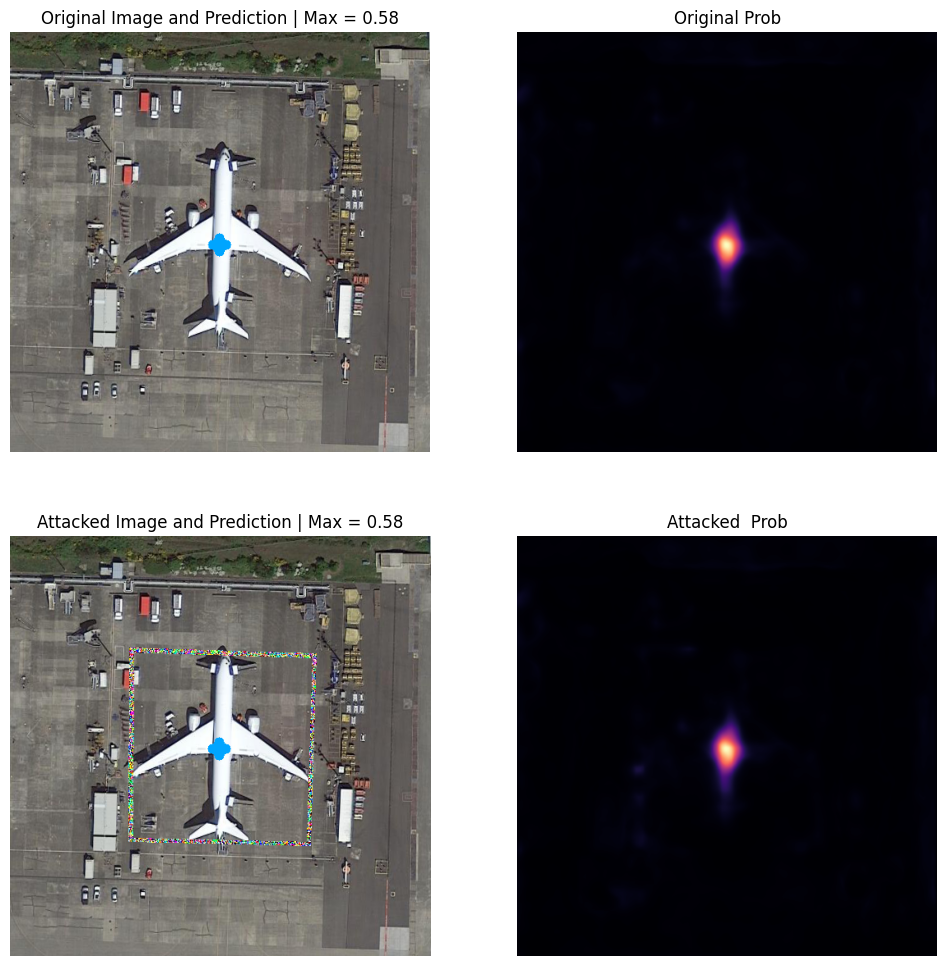

In [47]:
show_attack_results(img, mask, attack_t, device)

## Smarter patch 
The problem with the previous patch is that only a small part of the patch is trained in each imaged hence the training dpes not generamize to more 

In [48]:
import torch.nn.functional as F

In [49]:
import torch.nn.functional as F

def put_attack_square_border(img, attack, cx, cy, r, thickness, mode="bilinear"):
    """
    img:    [B, 3, H, W]
    attack: [1 or B, 3, thickness, L]   (e.g. L=400). Used for all 4 sides via interpolation.
    (cx, cy): center in (row, col) coordinates
    r: half-side of the square (side = 2r)
    thickness: border thickness in pixels
    """
    C, H, W = img.shape
    t = thickness
    attack_left = attack[:, :, :, :TILE_SIZE]
    attack_top = attack[:, :, :, TILE_SIZE:TILE_SIZE*2]
    attack_right = attack[:, :, :, TILE_SIZE*2:TILE_SIZE*3]
    attack_bottom = attack[:, :, :, TILE_SIZE*3:]
    

    # Square interior (clamped)
    x0 = max(cx - r, 0)
    x1 = min(cx + r, H)
    y0 = max(cy - r, 0)
    y1 = min(cy + r, W)

    # Helper: resize a horizontal strip [B,3,t,L] to [B,3,t,needed_w]
    def resize_h(strip, needed_w):
        return F.interpolate(strip, size=(t, needed_w), mode=mode, align_corners=False)

    # Helper: resize a vertical strip derived from same attack to [B,3,needed_h,t]
    def resize_v(strip, needed_h):
        # strip: [B,3,t,L] -> [B,3,L,t] then interpolate to (needed_h, t)
        strip_v = strip.permute(0, 1, 3, 2)
        out = F.interpolate(strip_v, size=(needed_h, t), mode=mode, align_corners=False)
        return out  # [B,3,needed_h,t]

    # TOP border (outside): rows [x0 - t, x0), cols [y0, y1)
    xt0, xt1 = max(x0 - t, 0), x0
    if xt1 > xt0 and y1 > y0:
        needed_h = xt1 - xt0
        needed_w = y1 - y0
        top = resize_h(attack_top, needed_w)          # [B,3,t,needed_w]
        top = top[:, :, :needed_h, :]            # crop if clamped near image top
        img[:, xt0:xt1, y0:y1] = top

    # BOTTOM border (outside): rows [x1, x1 + t), cols [y0, y1)
    xb0, xb1 = x1, min(x1 + t, H)
    if xb1 > xb0 and y1 > y0:
        needed_h = xb1 - xb0
        needed_w = y1 - y0
        bottom = resize_h(attack_bottom, needed_w)
        bottom = bottom[:, :, :needed_h, :]
        img[:, xb0:xb1, y0:y1] = bottom

    # LEFT border (outside): rows [x0, x1), cols [y0 - t, y0)
    yl0, yl1 = max(y0 - t, 0), y0
    if yl1 > yl0 and x1 > x0:
        needed_h = x1 - x0
        needed_w = yl1 - yl0  # this is thickness after clamping
        left = resize_v(attack_left, needed_h)        # [B,3,needed_h,t]
        left = left[:, :, :, :needed_w]          # crop if clamped near image left
        img[:, x0:x1, yl0:yl1] = left

    # RIGHT border (outside): rows [x0, x1), cols [y1, y1 + t)
    yr0, yr1 = y1, min(y1 + t, W)
    if yr1 > yr0 and x1 > x0:
        needed_h = x1 - x0
        needed_w = yr1 - yr0
        right = resize_v(attack_right, needed_h)
        right = right[:, :, :, :needed_w]
        img[:, x0:x1, yr0:yr1] = right

    return img

In [50]:
def apply_attack(imgs_t, metas, thickness, attack):
    attacked_imgs_t = imgs_t.clone()
    for i in range(imgs_t.shape[0]):
        meta = metas[i]
        img = attacked_imgs_t[i]
        for j in range(meta["num_objects"]):
            cx, cy = meta["centers"][j]
            area = meta["areas"][j]
            edge_size = np.floor(np.sqrt(area))
            r = int(np.floor(edge_size/2))
            img = put_attack_square_border(img, attack, cx, cy, r, thickness, mode="bilinear")
        attacked_imgs_t[i,:,:,:] = img   
    return attacked_imgs_t
            

In [51]:
import builtins
min = builtins.min
max = builtins.max

In [55]:
def validate_attack(model, attack, validation_loader):
    model.eval()
    cefunction = CenterLoss().to(device)
    validation_loss = 0.0
    max_prediction = []
    max_prediction_attacked = []
    with torch.inference_mode():
        for imgs_t, targets_t, metas, masks_t in tqdm(validation_loader, desc="validation", leave=False):
            imgs_t = imgs_t.to(device, non_blocking=True)
            masks_t = masks_t.to(device, non_blocking=True)
            pred_t = torch.sigmoid(model(imgs_t))
            imgs_attacked_t = apply_attack(imgs_t, metas, thickness, attack)
            pred_attacked_t = torch.sigmoid(model(imgs_attacked_t))
            loss = -cefunction(pred_t, pred_attacked_t)
            validation_loss += loss.item()
            max_prediction.append(pred_t.max().item())
            max_prediction_attacked.append(pred_attacked_t.max().item())
    max_prediction = np.array(max_prediction)
    max_prediction_attacked = np.array(max_prediction_attacked) 
    print("Average Max prediction unattacked: ", max_prediction.mean())
    print("Average Max prediction attacked: ", max_prediction_attacked.mean())
            
    return validation_loss, max_prediction, max_prediction_attacked


In [58]:
def train_attack_area(model,n_epoch, batch_loop, train_loader, validation_loader, thickness = 20, learning_rate = 0.5, early_stop = 1e8):# Init the attack
    with mlflow.start_run() as run:
        stop = False
        run_id = run.info.run_id
        print(f"ML Flow run id {run_id}")
        
        mlflow.log_param("n_epoch", n_epoch)
        mlflow.log_param("learning_rate", learning_rate)
        model.eval()
        # freeze gradient
        for p in model.parameters():
            p.requires_grad_(False)
        cefunction = CenterLoss().to(device)
        attack = None
        optimizer = None
        # epoch loop
        global_step = 0
        
        if attack is None:
            attack = torch.nn.Parameter(torch.rand([1,3,thickness,4*TILE_SIZE]))
            optimizer = torch.optim.AdamW([attack], lr=learning_rate)
            normalized_min = TF.normalize(torch.zeros_like(attack), DOTA_MEAN, DOTA_STD)
            normalized_max = TF.normalize(torch.ones_like(attack), DOTA_MEAN, DOTA_STD)
                          
        for epoch in tqdm(range(1, n_epoch+1), desc=run_id):
            # loop throught the batch
            training_loss = 0.0
            batch_count = 0
            
            for imgs_t, _, metas, masks_t in tqdm(train_loader, desc="train", leave=False):
                imgs_t = imgs_t.to(device, non_blocking=True)
                B = imgs_t.shape[0]
                masks_t = masks_t.to(device, non_blocking=True)

                with torch.no_grad():
                    pred_t = torch.sigmoid(model(imgs_t)).detach()               

                for _ in range(batch_loop):
                    optimizer.zero_grad(set_to_none=True)
                    imgs_attacked_t = apply_attack(imgs_t, metas, thickness, attack)
                    pred_attacked_t = torch.sigmoid(model(imgs_attacked_t))
                    
                    loss = - cefunction(pred_t, pred_attacked_t)
                    loss.backward()
                    optimizer.step()
                    
                    with torch.no_grad():
                        attack.clamp_(normalized_min, normalized_max)  # keeps it in image range, no new graph
                    
                    global_step += 1
                    training_loss += loss.item()
                    mlflow.log_metric("training_loss", loss.item(), step=global_step)
                    mlflow.log_metric("max prob original", pred_t.max().item(), step=global_step)
                    mlflow.log_metric("max prob attacked", pred_attacked_t.max().item(), step=global_step)
                
                if global_step>early_stop:
                    stop = True
                    break
                
                batch_count += 1
                
                if batch_count % 5 == 0:
                    tqdm.write(f"BATCH {batch_count:3d} | train: {training_loss/(B*batch_loop):.4f}")
                    training_loss = 0
                    attack_path = "runs/attack.pt"
                    torch.save(attack.detach().cpu(), attack_path)
                    mlflow.log_artifact(attack_path)
            
            validation_loss, max_prediction, max_prediction_attacked = validate_attack(model, attack, validation_loader)
            mlflow.log_metric("validation_loss", validation_loss, step=global_step) 
            mlflow.log_metric("max_prediction_unattacked", max_prediction.mean(), step=global_step)
            mlflow.log_metric("max_prediction_attacked", max_prediction_attacked.mean(), step=global_step)
                
            tqdm.write(f"EPOCH {epoch:3d} | train: {training_loss:.4f} | validation_loss: {validation_loss} | Average Max prediction original vs attacked: {max_prediction.mean()} vs {max_prediction_attacked.mean()}")
            
            if stop:
                break
            
        # save
        attack_path = f"runs/{run_id}attack.pt"
        torch.save(attack.detach().cpu(), attack_path)
        mlflow.log_artifact(attack_path)
    return attack, run_id


In [ ]:
n_epoch = 1
batch_loop = 10
thickness = 20
batch_size = 1
ttack, run_id = train_attack_area(model, n_epoch, batch_loop, train_loader, validation_loader,thickness = 10, learning_rate = 0.5, early_stop = 1)

ML Flow run id 7cf76b60945d46c980ace77c249cf2d5


7cf76b60945d46c980ace77c249cf2d5:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
def show_attack_results(img, mask, meta, attack_t, thickness, device):
    weight_map_t = get_gaussian_weight_map(TILE_SIZE, device)
    img_t = x_to_torch(img).to(device)
    mask_t = torch.from_numpy(mask).to(device)
    cefunction = CenterLoss().to(device)

    model.eval()
    with torch.no_grad():
        probality_map_unattacked_t = torch.sigmoid(model(img_t))*weight_map_t
        img_attacked_t = apply_attack(img_t, meta, thickness, attack_t)
        probality_map_attacked_t = torch.sigmoid(model(img_attacked_t))*weight_map_t
                
        loss = - cefunction(probality_map_unattacked_t, probality_map_attacked_t)
    
    loss_test = loss.item()
    
    img_unattacked, probality_map_unattacked = numpyfy_attack_results(img_t, probality_map_unattacked_t)
    img_attacked, probality_map_attacked = numpyfy_attack_results(img_attacked_t, probality_map_attacked_t)
    p_max_unattacked = probality_map_unattacked.max()
    p_max_attacked = probality_map_attacked.max()
    
    centers_unattacked = find_peaks(probality_map_unattacked, threshold=THRESHOLD)
    img_unattacked_cross = draw_centers(img_unattacked, centers_unattacked, (0, 165, 255), radius=radius, thickness=thickness)

    centers_attacked = find_peaks(probality_map_attacked, threshold=THRESHOLD)
    img_attacked_cross = draw_centers(img_attacked, centers_attacked, (0, 165, 255), radius=radius, thickness=thickness)

    ## Normalization
    # Make x and vis_pred float [0,1] too (if they are uint8 or 0..255 float)
    img_unattacked_cross = img_unattacked_cross.astype(np.float32) / 255.0
    img_attacked_cross = img_attacked_cross.astype(np.float32) / 255.0

    # Normalize prob_map to [0,1]
    probality_map_unattacked = probality_map_unattacked.astype(np.float32)
    pmin0, pmax0 = probality_map_unattacked.min(), probality_map_unattacked.max()
    probality_map_unattacked = (probality_map_unattacked - pmin0) / (pmax0 - pmin0 + 1e-8)
    # Colormap returns float in [0,1]
    probality_map_unattacked = plt.get_cmap("magma")(probality_map_unattacked)[..., :3]
    
    # Normalize prob_map to [0,1]
    probality_map_attacked = probality_map_attacked.astype(np.float32)
    pmin, pmax = probality_map_attacked.min(), probality_map_attacked.max()
    probality_map_attacked = (probality_map_attacked - pmin) / (pmax - pmin + 1e-8)
    # Colormap returns float in [0,1]
    probality_map_attacked = plt.get_cmap("magma")(probality_map_attacked)[..., :3]
    
    fig, ax = plt.subplots(2,2, figsize=(12,12))

    plt.title(f"Comparison of Detection with and Without Attack | Loss ={loss_test:.2f}")
    ax[0,0].imshow(img_unattacked_cross)
    ax[0,0].set_title(f"Original Image and Prediction | Max = {p_max_unattacked:.2f}")
    ax[0,1].imshow(probality_map_unattacked)
    ax[0,1].set_title("Original Prob")
    ax[1,0].imshow(img_attacked_cross)
    ax[1,0].set_title(f"Attacked Image and Prediction | Max = {p_max_attacked:.2f}")
    ax[1,1].imshow(probality_map_attacked)
    ax[1,1].set_title("Attacked  Prob")

    for ax in fig.axes:
        ax.axis("off")
    plt.show()

In [ ]:
img_path = "segdata/DOTA/DOTA_PLANES_TILED/train/image/P0023_obj_27.png"
mask_path = "segdata/DOTA/DOTA_PLANES_TILED/train/mask/P0023_obj_27.png"
img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
centers, areas = mask_to_centers(mask, return_areas=True)
meta = [{
    "centers": centers,
    "areas": areas,
    "num_objects": len(centers)
}]

In [ ]:
# run_id = "a16ca4566d6648368fa0d774c8455163"
artifact = [f.path for f in client.list_artifacts(run_id)]
path = client.download_artifacts(run_id, artifact[0])
attack_t = torch.load(path, map_location=device).to(device)
attack = attack_t.cpu().numpy()

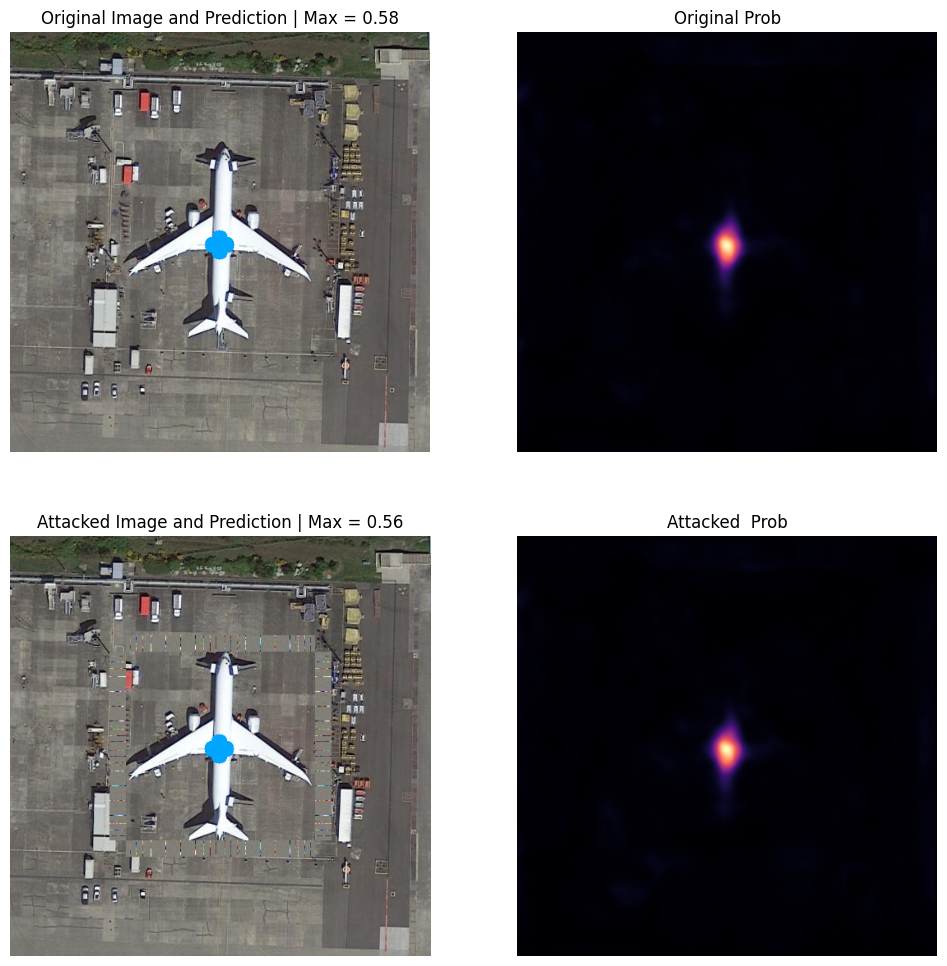

In [ ]:
show_attack_results(img, mask, meta, attack_t, thickness, 
                    device)